# 文件分類

**Author:** 黃天原  
本周課程為「文件分類」，主要使用文章轉DTM(document term matrix)的方式，將文章用不同的字詞分布表示，再利用python的sklearn套件，套用決策樹、logistic regression等方式訓練模型，以分辨不同的文件。本篇 Jupyter Notebook 將展示「中文」的文件分類，使用聯合新聞網的三個版別文章做示範。

## 分析目標
+ 資料內容：
    + 資料來源：聯合新聞網
    + 版別：股市、運動、兩岸  

* 分析主題：將聯合新聞網三個版別的文章合起來，訓練模型能預測新聞版別，再用分類模型進行文件的版別分類。

* 以下為教學目標：
    1. 如何將以數字向量代表一篇文章？
        * `CountVectorizer`
        * `TfidfVectorizer`
    2. 基本的分類模型流程，包含以下三步驟：
        * 前處理 (preprocess)
        * 建模 (train model)
        * 評估與預測 (evaluation and predict)
    3. cross validation
    4. 不同分類器的效果
    5. 可解釋的可視化模型結果
    6. 預測其他家新聞文章的版別

## 1. 套件說明
下面列出在本次實作過程中我們所使用到的相關套件，在這個Jupyter Notebook當中我們將會簡單的展示這些套件的使用方式，關於各個套件的進階使用請同學參照其官網的說明。
- **sklearn**: 全名為Scikit-learn，機器學習的常用建模套件，包含各種分群、分類、迴歸模型，如隨機森林、SVM或 K-means 等。
- pandas: 一個資料分析的函式庫，提供了DataFrame等資料格式，與資料處理的函數。
- jieba: 結巴套件，中文斷詞套件
- seaborn: 基於 matplotlib 封裝的繪圖工具

In [1]:
import re
from pprint import pprint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jieba
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, KFold
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    RocCurveDisplay
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

In [77]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = 'raw_data/SourceHanSansTW-Regular.otf'  # Your font path goes here
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()

Text(0.5, 1.0, '聲量圖')

C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\events.py:89: UserWarning: Glyph 32882 (\N{CJK UNIFIED IDEOGRAPH-8072}) missing from current font.
  func(*args, **kwargs)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\events.py:89: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  func(*args, **kwargs)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\events.py:89: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from current font.
  func(*args, **kwargs)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 32882 (\N{CJK UNIFIED IDEOGRAPH-8072}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  fig.canva

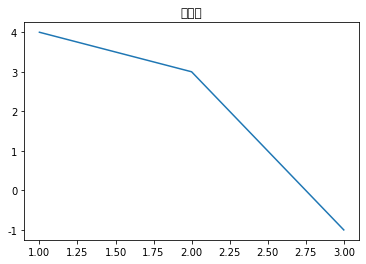

In [76]:
from matplotlib import font_manager
font_set = {f.name for f in font_manager.fontManager.ttflist}
# matplotlib.rcParams['font.family'] = ['Noto Sans Mono CJK TC', 'sans-serif']
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP"]
plt.plot((1, 2, 3), (4, 3, -1))
plt.title("聲量圖")

## 2. 文字前處理
`udn_news_03.csv`裡面包含了要分析的 udn 新聞資料。首先我們先看文集的基本資料，並做文集前處理。

In [4]:
udn = pd.read_csv("電影資料集.csv")  # 匯資料
udn.head(3)

,Unnamed: 0,index,system_id,insertedDate,artPoster,artIP,artType,artTitle,artDate,artTime,artUrl,artContent
0,0,0,0,2023-02-20 11:11:30,elvayanzimei,36.226.171.189,好看,[好雷]《駭客任務：復活》「選擇」抑或「選擇選擇」？,2022-01-01,11:23:13,https://www.ptt.cc/bbs/movie/M.1641007397.A.FA...,雷文防雷資訊頁_x000D_\n~*-*~*-*~*-*~*-*~*-*~*-*~*-*~*...
1,1,4,4,2023-02-20 10:57:44,dakkk,223.137.165.121,好看,[好雷] 金牌特務-金士曼起源,2022-01-01,10:11:17,https://www.ptt.cc/bbs/movie/M.1641003080.A.62...,雷文防雷資訊頁_x000D_\n~*-*~*-*~*-*~*-*~*-*~*-*~*-*~*...
2,2,6,6,2023-02-20 10:55:06,vuvuvuyu,111.249.74.134,好看,[好雷] 如何跨越家庭問題：對照美國女孩跟瀑布,2022-01-01,04:51:00,https://www.ptt.cc/bbs/movie/M.1640983862.A.BD...,上個週末抽空去看了美國女孩，散場時聽到觀眾在比較《美國女孩》跟《瀑布_x000D_\n》兩部...


In [5]:
# 看看有幾篇文章
print(f"number of posts: {udn.shape[0]}")
print(f"date range: {(udn['artDate'].min(), udn['artDate'].max())}")
print(f"category: \n{udn['artType'].value_counts()}")


number of posts: 3475
date range: ('2022-01-01', '2022-12-31')
category: 
好看    2258
普通     677
難看     540
Name: artType, dtype: int64


+ 2.1 斷句
+ 2.2 斷詞（刪掉次數太少的、標點符號、停用字）

### 2.1 清理

利用問號、句號或驚嘆號等符號斷句，或是如果出現中文或是英文的省略號，像是`...`也會斷句，最後設定會去除結尾的空白符號。

In [6]:
# 移除網址格式
udn["artContent"] = udn.artContent.apply(
    lambda x: re.sub("(http|https)://.*", "", x)
)
udn["artTitle"] = udn["artTitle"].apply(
    lambda x: re.sub("(http|https)://.*", "", x)
)
# 只留下中文字
udn["artContent"] = udn.artContent.apply(
    lambda x: re.sub("[^\u4e00-\u9fa5]+", "", x)
)
udn["artTitle"] = udn["artTitle"].apply(
    lambda x: re.sub("[^\u4e00-\u9fa5]+", "", x)
)
udn.head(3)

,Unnamed: 0,index,system_id,insertedDate,artPoster,artIP,artType,artTitle,artDate,artTime,artUrl,artContent
0,0,0,0,2023-02-20 11:11:30,elvayanzimei,36.226.171.189,好看,好雷駭客任務復活選擇抑或選擇選擇,2022-01-01,11:23:13,https://www.ptt.cc/bbs/movie/M.1641007397.A.FA...,雷文防雷資訊頁影片名稱駭客任務復活觀影時間觀影地點京站威秀第二週直接換到小廳觀影方式自行購票...
1,1,4,4,2023-02-20 10:57:44,dakkk,223.137.165.121,好看,好雷金牌特務金士曼起源,2022-01-01,10:11:17,https://www.ptt.cc/bbs/movie/M.1641003080.A.62...,雷文防雷資訊頁雷文主文分隔線做為起源的一部電影我覺得拍的很不錯有人說這部不能跟第一集看作同一...
2,2,6,6,2023-02-20 10:55:06,vuvuvuyu,111.249.74.134,好看,好雷如何跨越家庭問題對照美國女孩跟瀑布,2022-01-01,04:51:00,https://www.ptt.cc/bbs/movie/M.1640983862.A.BD...,上個週末抽空去看了美國女孩散場時聽到觀眾在比較美國女孩跟瀑布兩部作品當下就決定隔天去看瀑布覺...


In [7]:
udn.drop(udn.columns[udn.columns.str.contains('unnamed',case = False)],axis = 1, inplace = True)
udn.head(3)

,index,system_id,insertedDate,artPoster,artIP,artType,artTitle,artDate,artTime,artUrl,artContent
0,0,0,2023-02-20 11:11:30,elvayanzimei,36.226.171.189,好看,好雷駭客任務復活選擇抑或選擇選擇,2022-01-01,11:23:13,https://www.ptt.cc/bbs/movie/M.1641007397.A.FA...,雷文防雷資訊頁影片名稱駭客任務復活觀影時間觀影地點京站威秀第二週直接換到小廳觀影方式自行購票...
1,4,4,2023-02-20 10:57:44,dakkk,223.137.165.121,好看,好雷金牌特務金士曼起源,2022-01-01,10:11:17,https://www.ptt.cc/bbs/movie/M.1641003080.A.62...,雷文防雷資訊頁雷文主文分隔線做為起源的一部電影我覺得拍的很不錯有人說這部不能跟第一集看作同一...
2,6,6,2023-02-20 10:55:06,vuvuvuyu,111.249.74.134,好看,好雷如何跨越家庭問題對照美國女孩跟瀑布,2022-01-01,04:51:00,https://www.ptt.cc/bbs/movie/M.1640983862.A.BD...,上個週末抽空去看了美國女孩散場時聽到觀眾在比較美國女孩跟瀑布兩部作品當下就決定隔天去看瀑布覺...


In [8]:
udn_drop = ['index', 'artPoster','artIP', 'artDate', 'artTime']
udn = udn.drop(udn_drop, axis=1)
udn = udn.rename(columns={"artType": "artCatagory"})
udn = udn.rename(columns={"insertedDate": "artDate"})
udn

,system_id,artDate,artCatagory,artTitle,artUrl,artContent
0,0,2023-02-20 11:11:30,好看,好雷駭客任務復活選擇抑或選擇選擇,https://www.ptt.cc/bbs/movie/M.1641007397.A.FA...,雷文防雷資訊頁影片名稱駭客任務復活觀影時間觀影地點京站威秀第二週直接換到小廳觀影方式自行購票...
1,4,2023-02-20 10:57:44,好看,好雷金牌特務金士曼起源,https://www.ptt.cc/bbs/movie/M.1641003080.A.62...,雷文防雷資訊頁雷文主文分隔線做為起源的一部電影我覺得拍的很不錯有人說這部不能跟第一集看作同一...
2,6,2023-02-20 10:55:06,好看,好雷如何跨越家庭問題對照美國女孩跟瀑布,https://www.ptt.cc/bbs/movie/M.1640983862.A.BD...,上個週末抽空去看了美國女孩散場時聽到觀眾在比較美國女孩跟瀑布兩部作品當下就決定隔天去看瀑布覺...
3,13,2023-02-20 10:54:03,好看,好無雷金牌特務金士曼起源超越期待的精采,https://www.ptt.cc/bbs/movie/M.1640972128.A.56...,首先我不但是金牌特務粉也是馬修范恩粉特攻聯盟戰警第一戰都心中神作不管版上推文難看呼聲此起彼落...
4,14,2023-02-20 10:53:55,好看,好雷魔鬼剋星,https://www.ptt.cc/bbs/movie/M.1640970450.A.B9...,雷文防雷資訊頁雷文主文分隔線今晚是在公館東南亞看的昨天線上預約的時候本來沒人沒想到今天坐滿滿...
...,...,...,...,...,...,...
3470,14126,2023-02-18 10:07:34,普通,普負雷想見你眼淚記得你一切瞬間停在,https://www.ptt.cc/bbs/movie/M.1672375776.A.A6...,部落格版記得年的某一天在製作公司上班的學長突然問我有沒有興趣搶先看個幾集他們最新的電視劇然後...
3471,14130,2023-02-18 10:06:52,普通,普好雷邪惡的孩子以愛為名的惡,https://www.ptt.cc/bbs/movie/M.1672461216.A.BD...,部落格版本以為由導演片岡翔所構思的這部邪惡的孩子會是變調的灰姑娘加上盜愛之家的結合但他卻是把...
3472,14142,2023-02-18 10:05:14,普通,普負雷雷神索爾愛與雷霆鬆散的敘事結構,https://www.ptt.cc/bbs/movie/M.1672414171.A.87...,前幾天才在上補完雷神索爾愛與雷霆確實如板上普遍的評價一般不是很好看我個人覺得以劇本而言這部有...
3473,14149,2023-02-18 10:03:54,普通,普雷聖誕傾情輕鬆小品喜歡琳賽蘿涵別錯過,https://www.ptt.cc/bbs/movie/M.1672496599.A.54...,聖誕傾情劇情很簡單好猜整體來說是輕鬆溫馨小品很適合聖誕過年假期來看很久沒看到琳賽蘿涵的電影作...


文章的標題`artTitle`和內文`sentence`都會納入分析的內容，成為新的`content`欄位。

In [9]:
# 留下 content
udn["content"] = udn["artTitle"] + udn["artContent"]
udn = udn[["content", "artUrl", "artCatagory"]]  # 文章內容 文章連結
udn.head()

,content,artUrl,artCatagory
0,好雷駭客任務復活選擇抑或選擇選擇雷文防雷資訊頁影片名稱駭客任務復活觀影時間觀影地點京站威秀第...,https://www.ptt.cc/bbs/movie/M.1641007397.A.FA...,好看
1,好雷金牌特務金士曼起源雷文防雷資訊頁雷文主文分隔線做為起源的一部電影我覺得拍的很不錯有人說這...,https://www.ptt.cc/bbs/movie/M.1641003080.A.62...,好看
2,好雷如何跨越家庭問題對照美國女孩跟瀑布上個週末抽空去看了美國女孩散場時聽到觀眾在比較美國女孩...,https://www.ptt.cc/bbs/movie/M.1640983862.A.BD...,好看
3,好無雷金牌特務金士曼起源超越期待的精采首先我不但是金牌特務粉也是馬修范恩粉特攻聯盟戰警第一戰...,https://www.ptt.cc/bbs/movie/M.1640972128.A.56...,好看
4,好雷魔鬼剋星雷文防雷資訊頁雷文主文分隔線今晚是在公館東南亞看的昨天線上預約的時候本來沒人沒想...,https://www.ptt.cc/bbs/movie/M.1640970450.A.B9...,好看


In [10]:
# 看看有幾篇文章
print(f"total docs: {udn.shape[0]}")


total docs: 3475


### 2.2 斷詞

In [11]:
# 設定繁體中文詞庫
jieba.set_dictionary("./dict/dict.txt.big")

# 新增stopwords
# jieba.analyse.set_stop_words('./dict/stop_words.txt') #jieba.analyse.extract_tags才會作用
with open("./dict/stop_words.txt", encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

In [12]:
# 設定斷詞 function
def getToken(row):
    seg_list = jieba.cut(row, cut_all=False)
    seg_list = [
        w for w in seg_list if w not in stopWords and len(w) > 1
    ]  # 篩選掉停用字與字元數大於1的詞彙
    return seg_list

In [13]:
udn["words"] = udn["content"].apply(getToken).map(" ".join)
udn.head()

Building prefix dict from c:\Users\user\OneDrive\桌面\社媒\week11_classification\dict\dict.txt.big ...
Loading model from cache C:\Users\user\AppData\Local\Temp\jieba.u14d9f11a9cdce6ebddf71894ff56c016.cache
Loading model cost 1.306 seconds.
Prefix dict has been built successfully.
C:\Users\user\AppData\Local\Temp\ipykernel_18568\670672697.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  udn["words"] = udn["content"].apply(getToken).map(" ".join)


,content,artUrl,artCatagory,words
0,好雷駭客任務復活選擇抑或選擇選擇雷文防雷資訊頁影片名稱駭客任務復活觀影時間觀影地點京站威秀第...,https://www.ptt.cc/bbs/movie/M.1641007397.A.FA...,好看,好雷 駭客 任務 復活 選擇 選擇 選擇 雷文 防雷 資訊 影片名稱 駭客 任務 復活 觀影...
1,好雷金牌特務金士曼起源雷文防雷資訊頁雷文主文分隔線做為起源的一部電影我覺得拍的很不錯有人說這...,https://www.ptt.cc/bbs/movie/M.1641003080.A.62...,好看,好雷 金牌 特務 金士曼 起源 雷文 防雷 資訊 雷文 主文 分隔線 起源 一部 電影 覺得...
2,好雷如何跨越家庭問題對照美國女孩跟瀑布上個週末抽空去看了美國女孩散場時聽到觀眾在比較美國女孩...,https://www.ptt.cc/bbs/movie/M.1640983862.A.BD...,好看,好雷 跨越 家庭 問題 對照 美國 女孩 瀑布 上個 週末 抽空去 美國 女孩 散場 聽到 ...
3,好無雷金牌特務金士曼起源超越期待的精采首先我不但是金牌特務粉也是馬修范恩粉特攻聯盟戰警第一戰...,https://www.ptt.cc/bbs/movie/M.1640972128.A.56...,好看,好無雷 金牌 特務 金士曼 起源 超越 期待 精采 金牌 特務 修范恩粉 特攻 聯盟 戰警 ...
4,好雷魔鬼剋星雷文防雷資訊頁雷文主文分隔線今晚是在公館東南亞看的昨天線上預約的時候本來沒人沒想...,https://www.ptt.cc/bbs/movie/M.1640970450.A.B9...,好看,好雷 魔鬼 剋星 雷文 防雷 資訊 雷文 主文 分隔線 今晚 公館 東南亞 昨天 線上 預約...


### 2.3 資料集基本檢視

檢視資料內容

In [14]:
good = udn.loc[udn['artCatagory'] == '好看'].sample(n=540)

# 將所有其他 artcategory 的資料合併回來
other = udn.loc[udn['artCatagory'] != '好看']
udn = pd.concat([good, other])

In [15]:
print(f"total posts: {len(udn['artUrl'].unique())}")
print(f"category: \n{udn['artCatagory'].value_counts()}")


total posts: 1715
category: 
普通    677
好看    540
難看    540
Name: artCatagory, dtype: int64


## 3. 分類模型的訓練流程
### 3.1 根據7:3的比例切分資料集
利用 sklearn 中的 train_test_split 函數將 `raw_data` 隨機切成 7:3，設置 random_state 讓每次切分的結果一致。`y_train`和`y_test`分別為訓練資料和測試資料的預測目標（每個句子所屬的書名id）。

In [16]:
data = udn
X = data["words"]
y = data["artCatagory"]

# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777
)

print(X_train.head())
print(y_train.head())

2353    極負雷 蝙蝠俠 節奏 無腦 牽強 劇情 雷文 防雷 資訊 雷文 主文 分隔線 週末 蝙蝠俠 ...
864     微好雷 怪胎 世界 雷文 主文 分隔線 片名 中段 發生 身上 超能力 還以 一部 不想 女...
1429    好雷 象棋 故事 德奧 上週 院線 德國 永別 柏林 兩位 德國 蘿拉獎 影帝 對戲 翻翻 ...
2290    負雷 永恆 格局 超大 能力 超小 永恆 原來 光之城 看過 暮光 之城 相信 暮光 之城 ...
2520    負雷 世界 雷文 防雷 資訊 雷文 主文 分隔線 覺得 主要 問題 氣氛 營造 太糟 整個 ...
Name: words, dtype: object
2353    難看
864     好看
1429    好看
2290    難看
2520    難看
Name: artCatagory, dtype: object


In [17]:
# 看一下各個資料集切分的比例，應該要一致
print(
    f"raw data percentage :\n{data['artCatagory'].value_counts(normalize=True) * 100}"
)
print(f"\ntrain percentage :\n{y_train.value_counts(normalize=True) * 100}")
print(f"\ntest percentage :\n{y_test.value_counts(normalize=True) * 100}")

raw data percentage :
普通    38.531588
好看    30.734206
難看    30.734206
Name: artCatagory, dtype: float64

train percentage :
普通    38.323841
好看    31.244915
難看    30.431245
Name: artCatagory, dtype: float64

test percentage :
普通    39.015152
難看    31.439394
好看    29.545455
Name: artCatagory, dtype: float64


### 3.2 將文章轉為 DTM

DTM(document term matrix) :
+ 將不同的文章 (document) 以文章中出現過的字詞(term)表示
    + row 是document (文件)
    + column 是字詞 (term)
    + row 內的數字是出現的字數

DTM裡面的值可以有不同的表示方法
+ (1) 依據詞頻 (classic BoW)
    + 用 `CountVectorizer()`
    + unigrams and bigrams
    + [sklearn.feature_extraction.text.CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)
+ (2) 依據tfidf (advanced variant of BoW)
    + 篩選出現次數大於10的字
    + 用 `TfidfVectorizer()`
    + [sklearn.feature_extraction.text.TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)
+ 常用參數介紹
    + max_features: 取 詞頻 / tfidf 前多少的字
    + min_df: 篩選出現次數大於10的字(可以自行定義要不要篩選，可能會造成準確度下降)

在這裡我們用簡單的四個中文句子，建立一個 DTM，在這裡我們利用 `CountVectorizer` 計算出不同句子的詞頻，再轉換成DTM。DTM裡面每個row代表一個句子，每個column代表一個詞出現的次數。

### 3.3 套入正式的資料集
+  模型訓練範例: logistic regression + cv tokenizer

In [18]:
vectorizer = CountVectorizer(max_features=1000)
print(vectorizer)

CountVectorizer(max_features=1000)


In [19]:
X_train.head()

2353    極負雷 蝙蝠俠 節奏 無腦 牽強 劇情 雷文 防雷 資訊 雷文 主文 分隔線 週末 蝙蝠俠 ...
864     微好雷 怪胎 世界 雷文 主文 分隔線 片名 中段 發生 身上 超能力 還以 一部 不想 女...
1429    好雷 象棋 故事 德奧 上週 院線 德國 永別 柏林 兩位 德國 蘿拉獎 影帝 對戲 翻翻 ...
2290    負雷 永恆 格局 超大 能力 超小 永恆 原來 光之城 看過 暮光 之城 相信 暮光 之城 ...
2520    負雷 世界 雷文 防雷 資訊 雷文 主文 分隔線 覺得 主要 問題 氣氛 營造 太糟 整個 ...
Name: words, dtype: object

In [20]:
vectorizer.fit(X_train)
vec_train = vectorizer.transform(X_train)
vec_train

<1229x1000 sparse matrix of type '<class 'numpy.int64'>'
	with 98830 stored elements in Compressed Sparse Row format>

In [21]:
### 用 `toarray()` 轉成 numpy array
vec_train.toarray()

array([[1, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0]], dtype=int64)

In [22]:
# 可用 `fit_transform()` 一次完成
vec_train = vectorizer.fit_transform(X_train)
print(vectorizer.get_feature_names()[:10])


['一下', '一些', '一人', '一位', '一半', '一句', '一堆', '一場', '一天', '一定']


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [23]:
# fit 完後，可以用 `vocabulary_` 看到詞的 feature index
print(vectorizer.vocabulary_)
vectorizer.vocabulary_['一些']

{'蝙蝠俠': 800, '節奏': 726, '劇情': 160, '雷文': 955, '防雷': 946, '資訊': 864, '主文': 53, '分隔線': 145, '真的': 694, '不行': 42, '一直': 14, '蝙蝠': 799, '一種': 15, '最後': 531, '設定': 836, '所有': 444, '打架': 448, '電影': 957, '社會': 702, '格局': 555, '中間': 51, '炸彈': 609, '現在': 642, '還會': 918, '覺得': 820, '題材': 976, '這裡': 894, '已經': 337, '差點': 336, '有夠': 537, '不用': 39, '看不懂': 683, '知道': 698, '不合理': 33, '事實': 68, '每個': 574, '背後': 773, '很大': 374, '根本': 554, '謎語': 853, '無聊': 612, '一下': 0, '這是': 890, '聽到': 771, '反派': 185, '緊張': 752, '一些': 1, '畫面': 661, '可怕': 191, '莫名': 790, '爆炸': 619, '有沒有': 541, '看過': 689, '觀眾': 823, '唯一': 210, '反正': 184, '存在': 284, '應該': 430, '看到': 685, '難看': 954, '真實': 690, '心得': 388, '不想': 37, '刻意': 148, '像是': 115, '以為': 92, '從頭到尾': 382, '配角': 931, '魅力': 992, '問題': 212, '世界': 47, '片名': 627, '發生': 673, '身上': 872, '還以': 915, '一部': 20, '女兒': 263, '接觸': 463, '爸爸': 624, '故事': 488, '沒想到': 587, '使用': 99, '能力': 775, '比較': 577, '可惜': 192, '片中': 626, '表現': 807, '演技': 605, '裡面': 811, '整部': 493, '穿越': 710, '空間': 7

1

In [24]:
# 不需重新 `fit()` data，因前面已經 `fit()` 過了
vec_test = vectorizer.transform(X_test)
print(vec_train.shape)
print(vec_test.shape)


(1229, 1000)
(528, 1000)


In [25]:
# 建立分類器模型
clf = LogisticRegression()
clf.fit(vec_train, y_train)
clf

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [26]:
clf.classes_


array(['好看', '普通', '難看'], dtype=object)

In [27]:
y_pred = clf.predict(vec_test)
y_pred_proba = clf.predict_proba(vec_test)
print(y_pred[:10])

['好看' '難看' '難看' '難看' '難看' '普通' '普通' '普通' '普通' '普通']


In [28]:
print(y_pred_proba.shape)
y_pred_proba[0,:]

(528, 3)


array([0.8213878 , 0.16268837, 0.01592383])

In [29]:
## Accuracy, Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          好看       0.74      0.75      0.75       156
          普通       0.73      0.77      0.75       206
          難看       0.82      0.76      0.79       166

    accuracy                           0.76       528
   macro avg       0.77      0.76      0.76       528
weighted avg       0.76      0.76      0.76       528



In [30]:
classes = clf.classes_
cm = confusion_matrix(y_test, y_pred)
cm

array([[117,  29,  10],
       [ 30, 159,  17],
       [ 11,  29, 126]], dtype=int64)

(array([0.5, 1.5, 2.5]),
 [Text(0, 0.5, '好看'), Text(0, 1.5, '普通'), Text(0, 2.5, '難看')])

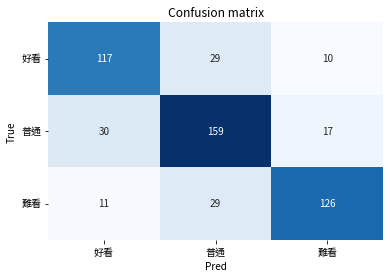

In [79]:
## Plot confusion matrix
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=plt.cm.Blues, cbar=False)
ax.set(
    xlabel="Pred",
    ylabel="True",
    xticklabels=classes,
    yticklabels=classes,
    title="Confusion matrix",
)
plt.yticks(rotation=0)

In [32]:
# one-hot encoding
label_binarizer = LabelBinarizer()
label_binarizer.fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
print(y_onehot_test.shape)  # (n_samples, n_classes)
y_onehot_test[0,:]

(528, 3)


array([1, 0, 0])

In [33]:
y_test.iloc[0]

'好看'

C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 22909 (\N{CJK UNIFIED IDEOGRAPH-597D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 30475 (\N{CJK UNIFIED IDEOGRAPH-770B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 38627 (\

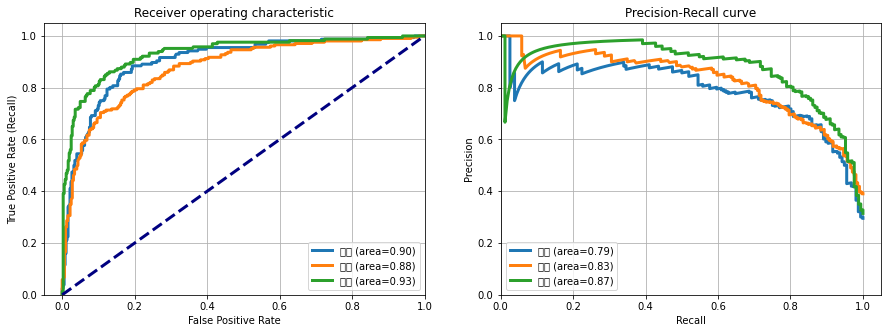

In [34]:
# plot ROC curve and precision-recall curve
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
## Plot roc
for i in range(len(classes)):
    fpr, tpr, thresholds = roc_curve(y_onehot_test[:, i], y_pred_proba[:, i])
    ax[0].plot(
        fpr, tpr, lw=3, label="{0} (area={1:0.2f})".format(classes[i], auc(fpr, tpr))
    )
ax[0].plot([0, 1], [0, 1], color="navy", lw=3, linestyle="--")
ax[0].set(
    xlim=[-0.05, 1.0],
    ylim=[0.0, 1.05],
    xlabel="False Positive Rate",
    ylabel="True Positive Rate (Recall)",
    title="Receiver operating characteristic",
)
ax[0].legend(loc="lower right")
ax[0].grid(True)

## Plot precision-recall curve
for i in range(len(classes)):
    precision, recall, thresholds = precision_recall_curve(
        y_onehot_test[:, i], y_pred_proba[:, i]
    )
    ax[1].plot(
        recall,
        precision,
        lw=3,
        label="{0} (area={1:0.2f})".format(classes[i], auc(recall, precision)),
    )
ax[1].set(
    xlim=[0.0, 1.05],
    ylim=[0.0, 1.05],
    xlabel="Recall",
    ylabel="Precision",
    title="Precision-Recall curve",
)
ax[1].legend(loc="best")
ax[1].grid(True)

plt.show()


### 3.4 tfidf

改試試看使用 tf-idf 的 DTM 來代表文章，訓練分類模型的效果

In [35]:
vectorizer = TfidfVectorizer(max_features=1000)
vec_train = vectorizer.fit_transform(X_train)
vec_test = vectorizer.transform(X_test)
vec_train.toarray()[0,:]

array([0.04719485, 0.05263212, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.13238726,
       0.12319693, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.08213512, 0.        ,
       0.        , 0.        , 0.25863184, 0.        , 0.13107451,
       0.        , 0.        , 0.13450848, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.06381481, 0.        , 0.03698709, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.08621431, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [36]:
clf.fit(vec_train, y_train)
y_pred = clf.predict(vec_test)
y_pred_proba = clf.predict_proba(vec_test)

# results
## Accuracy, Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          好看       0.72      0.69      0.70       156
          普通       0.68      0.73      0.70       206
          難看       0.79      0.75      0.77       166

    accuracy                           0.72       528
   macro avg       0.73      0.72      0.73       528
weighted avg       0.73      0.72      0.72       528



效果一樣也是不錯，可能因為三格新聞版別本來就有很大的差異，用字遣詞會不同。

### 3.5 CV

接著介紹 cross-validation。CV 在機器學習中，是一個很常用來讓模型評估能夠得到更穩定的數值的手法。

* figure1: 

<img src="https://scikit-learn.org/stable/_images/grid_search_workflow.png"  width="1000">

* figure 2:  

![](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

source: <https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-and-model-selection>

cross-validation 會自動切成 k 組 train-test dataset。  
`cross_validate()` 會回傳經過 cross-validation 的模型評估結果。

In [37]:
clf = LogisticRegression()
vec_train = CountVectorizer(max_features=1000).fit_transform(X_train)

scores = cross_validate(clf, vec_train, y_train, cv=5, scoring=("f1_macro", "recall_macro", "precision_macro"), return_estimator=True)
pprint(scores)

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

{'estimator': [LogisticRegression(),
               LogisticRegression(),
               LogisticRegression(),
               LogisticRegression(),
               LogisticRegression()],
 'fit_time': array([0.20405245, 0.11878252, 0.15821052, 0.18945384, 0.13619232]),
 'score_time': array([0.00300002, 0.00307393, 0.00699949, 0.00746298, 0.00507617]),
 'test_f1_macro': array([0.77435478, 0.77723059, 0.75816546, 0.75738586, 0.78798186]),
 'test_precision_macro': array([0.7785544 , 0.77840069, 0.76029221, 0.75678671, 0.79246895]),
 'test_recall_macro': array([0.77170796, 0.7779491 , 0.75720242, 0.75847953, 0.78556866])}


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


`cross_val_predict()` 則會回傳 cv 預測的類別。

In [38]:
y_pred = cross_val_predict(clf, vec_train, y_train, cv=5)
print(classification_report(y_train, y_pred))

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

              precision    recall  f1-score   support

          好看       0.79      0.78      0.78       384
          普通       0.75      0.76      0.75       471
          難看       0.79      0.76      0.78       374

    accuracy                           0.77      1229
   macro avg       0.77      0.77      0.77      1229
weighted avg       0.77      0.77      0.77      1229



c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

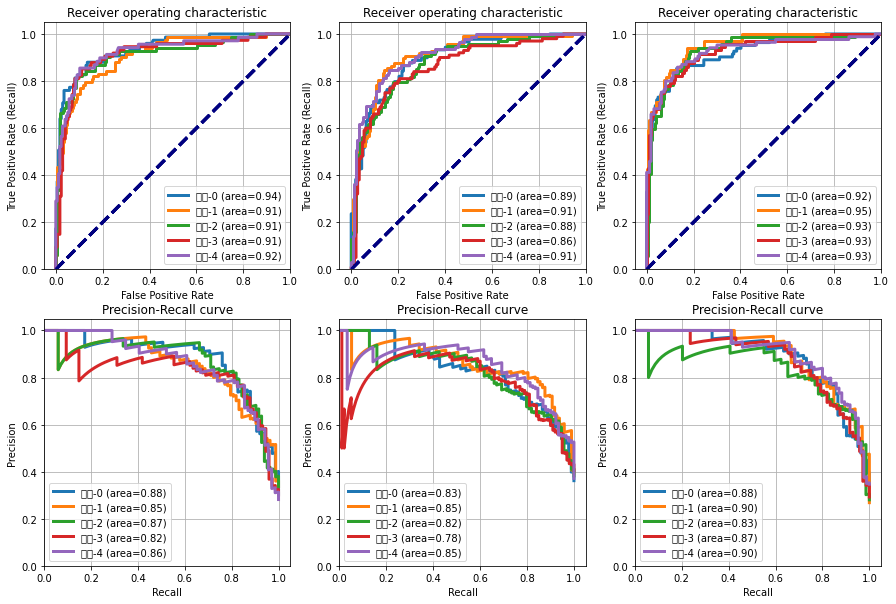

In [61]:
## 將三個新聞類別的 ROC curve 分別畫出來，並在同一張圖上比較不同 fold 的結果
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
kf = KFold(n_splits=5)
classes = scores['estimator'][0].classes_

for k, (train, test) in enumerate(kf.split(vec_train, y_train)):
    clf.fit(vec_train[train,:], y_train.iloc[train])
    y_pred = clf.predict(vec_train[test,:])    
    y_test = y_train.iloc[test]
    y_pred_proba = clf.predict_proba(vec_train[test,:])
    y_onehot_test = label_binarizer.transform(y_test)        
    

    ## Plot roc
    for i in range(len(classes)):
        fpr, tpr, thresholds = roc_curve(y_onehot_test[:, i], y_pred_proba[:, i])
        ax[0,i].plot(
            fpr,
            tpr,
            lw=3,
            label="{0}-{1} (area={2:0.2f})".format(classes[i], k, auc(fpr, tpr)),
        )
        ax[0,i].plot([0, 1], [0, 1], color="navy", lw=3, linestyle="--")
        ax[0,i].set(
            xlim=[-0.05, 1.0],
            ylim=[0.0, 1.05],
            xlabel="False Positive Rate",
            ylabel="True Positive Rate (Recall)",
            title="Receiver operating characteristic",
        )
        ax[0,i].legend(loc="best")
        ax[0,i].grid(True)

    ## Plot precision-recall curve
    for i in range(len(classes)):
        precision, recall, thresholds = precision_recall_curve(
            y_onehot_test[:, i], y_pred_proba[:, i]
        )
        ax[1,i].plot(
            recall,
            precision,
            lw=3,
            label="{0}-{1} (area={2:0.2f})".format(classes[i], k,auc(recall, precision)),
        )
        ax[1,i].set(
            xlim=[0.0, 1.05],
            ylim=[0.0, 1.05],
            xlabel="Recall",
            ylabel="Precision",
            title="Precision-Recall curve",
        )
        ax[1,i].legend(loc="best")
        ax[1,i].grid(True)

plt.show()

## 4. 比較不同模型效果

In [62]:
# 定義模型訓練組合
## pipeline: 資料處理 vectorizer + 分類器 clf
## 由於 cross-validation 會自動將資料分成 train/test，因此 input 只要給 X, y 即可

def train_cv(vectorizer, clf, X, y):

    ## train classifier
    vec_X = vectorizer.fit_transform(X).toarray()
    
    ## get cv results
    cv_results = cross_validate(clf, vec_X, y, cv=5, return_estimator=True)
    y_pred = cross_val_predict(clf, vec_X, y, cv=5)
    y_pred_proba = cross_val_predict(clf, vec_X, y, cv=5, method="predict_proba")
    
    ## Accuracy, Precision, Recall, F1-score
    cls_report = classification_report(y, y_pred, output_dict=True)
    print(classification_report(y, y_pred))

    classes = cv_results['estimator'][0].classes_
    
    ## Plot confusion matrix
    cm = confusion_matrix(y, y_pred)
    fig, ax = plt.subplots()
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=plt.cm.Blues, cbar=False)
    ax.set(
        xlabel="Pred",
        ylabel="True",
        xticklabels=classes,
        yticklabels=classes,
        title="Confusion matrix",
    )
    plt.yticks(rotation=0)


    fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

    kf = KFold(n_splits=5)
    
    for k, (train, test) in enumerate(kf.split(vec_X, y)):
        clf.fit(vec_X[train,:], y.iloc[train])
        y_pred = clf.predict(vec_X[test,:])    
        y_test = y.iloc[test]
        y_pred_proba = clf.predict_proba(vec_X[test,:])
        y_onehot_test = label_binarizer.transform(y_test)        
        
    
        ## Plot roc
        for i in range(len(classes)):
            fpr, tpr, thresholds = roc_curve(y_onehot_test[:, i], y_pred_proba[:, i])
            ax[0,i].plot(
                fpr,
                tpr,
                lw=3,
                label="{0}-{1} (area={2:0.2f})".format(classes[i], k, auc(fpr, tpr)),
            )
            ax[0,i].plot([0, 1], [0, 1], color="navy", lw=3, linestyle="--")
            ax[0,i].set(
                xlim=[-0.05, 1.0],
                ylim=[0.0, 1.05],
                xlabel="False Positive Rate",
                ylabel="True Positive Rate (Recall)",
                title="Receiver operating characteristic",
            )
            ax[0,i].legend(loc="best")
            ax[0,i].grid(True)

        ## Plot precision-recall curve
        for i in range(len(classes)):
            precision, recall, thresholds = precision_recall_curve(
                y_onehot_test[:, i], y_pred_proba[:, i]
            )
            ax[1,i].plot(
                recall,
                precision,
                lw=3,
                label="{0}-{1} (area={2:0.2f})".format(classes[i], k,auc(recall, precision)),
            )
            ax[1,i].set(
                xlim=[0.0, 1.05],
                ylim=[0.0, 1.05],
                xlabel="Recall",
                ylabel="Precision",
                title="Precision-Recall curve",
            )
            ax[1,i].legend(loc="best")
            ax[1,i].grid(True)

    plt.show()

    clf.fit(vec_X, y)
    # return the model object
    return cls_report

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

              precision    recall  f1-score   support

          好看       0.79      0.78      0.78       384
          普通       0.75      0.77      0.76       471
          難看       0.79      0.76      0.78       374

    accuracy                           0.77      1229
   macro avg       0.77      0.77      0.77      1229
weighted avg       0.77      0.77      0.77      1229



c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

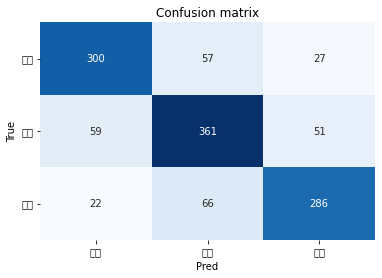

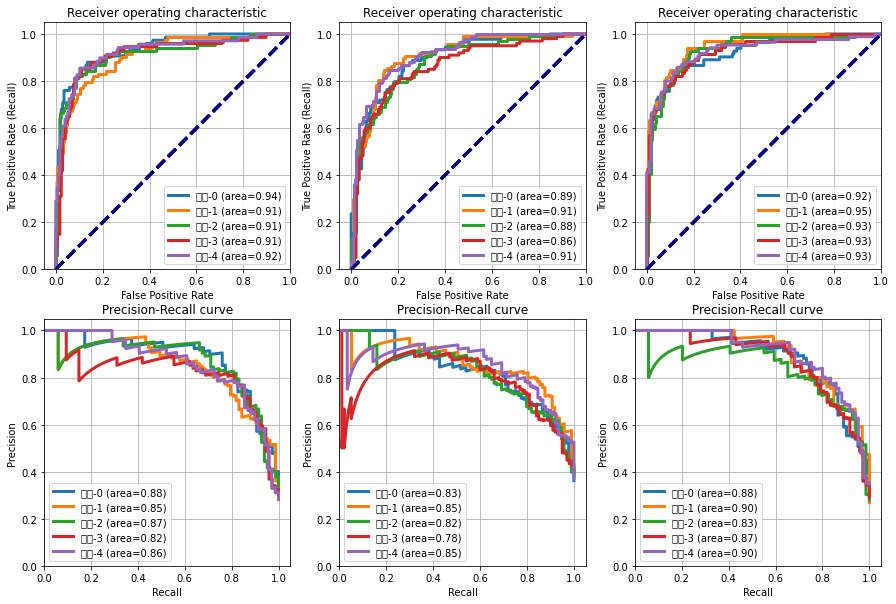

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
vectorizer = CountVectorizer(max_features=1000)
clf = LogisticRegression()
result = train_cv(vectorizer, clf, X_train, y_train)

now training: clf_logistic


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

              precision    recall  f1-score   support

          好看       0.79      0.78      0.78       384
          普通       0.75      0.77      0.76       471
          難看       0.79      0.76      0.78       374

    accuracy                           0.77      1229
   macro avg       0.77      0.77      0.77      1229
weighted avg       0.77      0.77      0.77      1229



c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

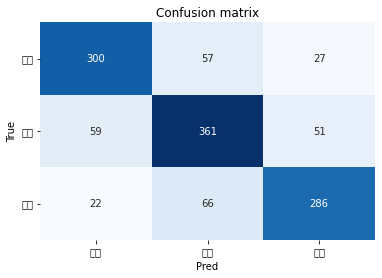

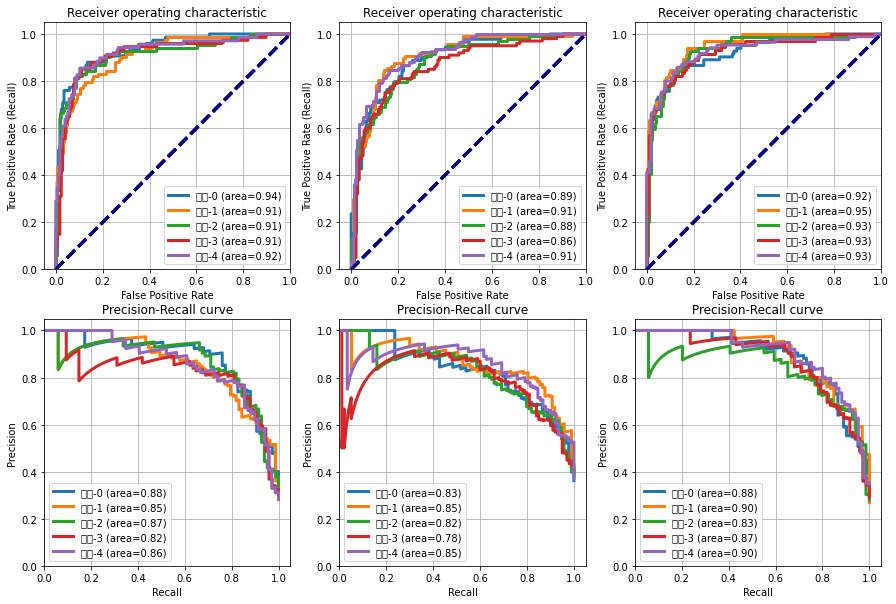

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


now training: clf_dtree
              precision    recall  f1-score   support

          好看       0.80      0.77      0.79       384
          普通       0.78      0.79      0.79       471
          難看       0.79      0.80      0.80       374

    accuracy                           0.79      1229
   macro avg       0.79      0.79      0.79      1229
weighted avg       0.79      0.79      0.79      1229



C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 22909 (\N{CJK UNIFIED IDEOGRAPH-597D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 30475 (\N{CJK UNIFIED IDEOGRAPH-770B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 38627 (\

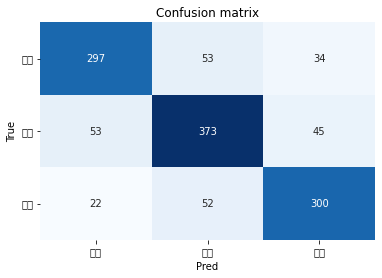

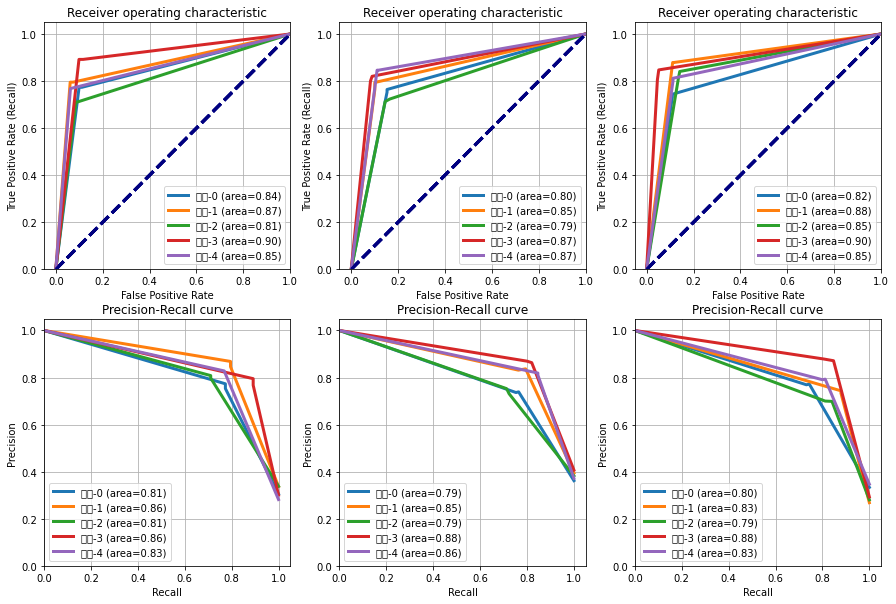

In [64]:
# 準備訓練資料
X = data["words"]
y = data["artCatagory"]

# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777
)
# 定義模型訓練組合
model_set = dict()
model_set['clf_logistic'] = LogisticRegression()
model_set['clf_dtree'] = DecisionTreeClassifier()
# model_set['clf_rf'] = RandomForestClassifier()
# 定義 vectorizer
vectorizer = CountVectorizer(max_features=1000)
# 存結果
result_set = dict()

for k, model in model_set.items():
    print("="*100)
    print(f"now training: {k}")
    result_set[k] = train_cv(vectorizer, model, X_train, y_train)
    print("="*100)


In [65]:
result_set['clf_logistic']

{'好看': {'precision': 0.7874015748031497,
  'recall': 0.78125,
  'f1-score': 0.7843137254901962,
  'support': 384},
 '普通': {'precision': 0.7458677685950413,
  'recall': 0.7664543524416136,
  'f1-score': 0.756020942408377,
  'support': 471},
 '難看': {'precision': 0.7857142857142857,
  'recall': 0.7647058823529411,
  'f1-score': 0.7750677506775069,
  'support': 374},
 'accuracy': 0.7705451586655818,
 'macro avg': {'precision': 0.7729945430374922,
  'recall': 0.7708034115981849,
  'f1-score': 0.7718008061920267,
  'support': 1229},
 'weighted avg': {'precision': 0.7709707620747086,
  'recall': 0.7705451586655818,
  'f1-score': 0.7706571791830501,
  'support': 1229}}

In [66]:
max = 0
best_model_name = ""
best_model_metric = "f1-score"

## choose max f1-score model from result_set
for k, v in result_set.items():
    if v['macro avg'][best_model_metric] > max:
        max = v['macro avg'][best_model_metric]
        best_model_name = k
print(f"best model: {best_model_name}")
pprint(result_set[best_model_name])

best model: clf_dtree
{'accuracy': 0.789259560618389,
 'macro avg': {'f1-score': 0.7895392188084434,
               'precision': 0.7900928510132855,
               'recall': 0.7891695322937128,
               'support': 1229},
 'weighted avg': {'f1-score': 0.7892359126654198,
                  'precision': 0.7893901695881977,
                  'recall': 0.789259560618389,
                  'support': 1229},
 '好看': {'f1-score': 0.7857142857142857,
        'precision': 0.7983870967741935,
        'recall': 0.7734375,
        'support': 384},
 '普通': {'f1-score': 0.78609062170706,
        'precision': 0.7803347280334728,
        'recall': 0.7919320594479831,
        'support': 471},
 '難看': {'f1-score': 0.7968127490039841,
        'precision': 0.7915567282321899,
        'recall': 0.8021390374331551,
        'support': 374}}


In [73]:
y_pred = model_set['clf_logistic'].predict(vectorizer.transform(X_test))
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          好看       0.74      0.75      0.75       156
          普通       0.73      0.77      0.75       206
          難看       0.82      0.76      0.79       166

    accuracy                           0.76       528
   macro avg       0.77      0.76      0.76       528
weighted avg       0.76      0.76      0.76       528



In [74]:
model_set['clf_logistic'].predict(vectorizer.transform(["電影 不錯 精彩 刺激 畫面 鏡頭 拍攝手法好 電影院 座位 氣氛好 安靜"]))

array(['普通'], dtype=object)

* logistic 的模型表現比決策樹的略好一點。
* 另外也可以嘗試用 tfidf 作為 `vectorizer`，比較看看相較直接的詞頻表，是否效果更好。
* 當 label 的類別不平衡的時候，會需要用其他手法或更複雜的模型，來解決資料類別不平衡的問題

## 5. 分析可解釋模型的結果

### 5.1 各字詞特徵的estimate係數
對於線性的模型，可以藉由相關係數，查看資料特徵（詞）對於判斷分類的影響
+ coefficient estimate 代表特徵每增加一單位（在此處會是該文章的某字詞頻 +1），y是1的發生機率比y是0的發生機率多幾倍（odds ratio 勝算比）
+ 這裡舉logistic regression + cv tokenizer 為例

In [69]:
from sklearn.linear_model import LogisticRegression
model_set['logistic_regression_cv'] = LogisticRegression()
best_model_name = 'logistic_regression_cv'

In [48]:
model_set[best_model_name]

LogisticRegression()

In [71]:
def plot_coef(logistic_reg_model, feature_names, top_n=10):
    # 選出某個類別的前10大影響力字詞
    log_odds = logistic_reg_model.coef_.T
    coef_df = pd.DataFrame(
        log_odds, 
        columns=logistic_reg_model.classes_, index=feature_names
    )
    for label in coef_df.columns:
        select_words = (
            coef_df[[label]]
            .sort_values(by=label, ascending=False)
            .iloc[np.r_[0:top_n, -top_n:0]]
        )
        word = select_words.index
        count = select_words[label]
        category_colors = np.where(
            select_words[label] >= 0, "darkseagreen", "rosybrown"
        )  # 設定顏色

        fig, ax = plt.subplots(figsize=(8, top_n*0.8))  # 設定畫布
        plt.rcParams["axes.unicode_minus"] = False

        ax.barh(word, count, color=category_colors)
        ax.invert_yaxis()
        ax.set_title(
            "Coeff increase/decrease odds ratio of 「" + label + "」 label the most",
            loc="left",
            size=16,
        )
        ax.set_ylabel("word", size=14)
        ax.set_xlabel("Word Frequency", size=14)

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


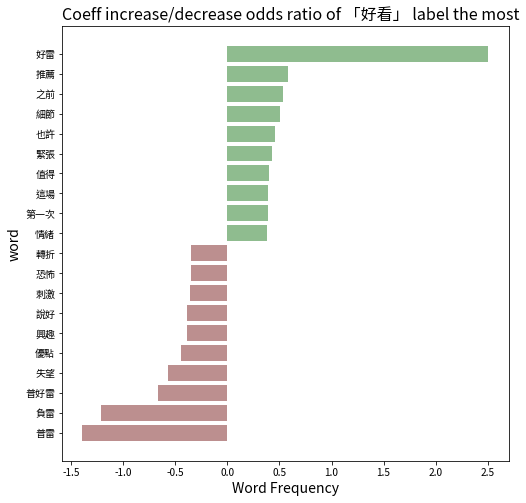

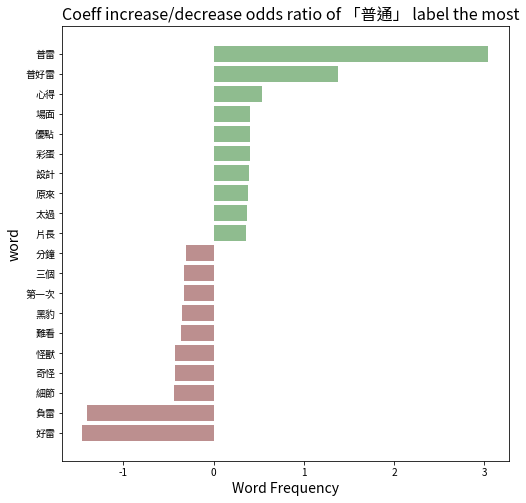

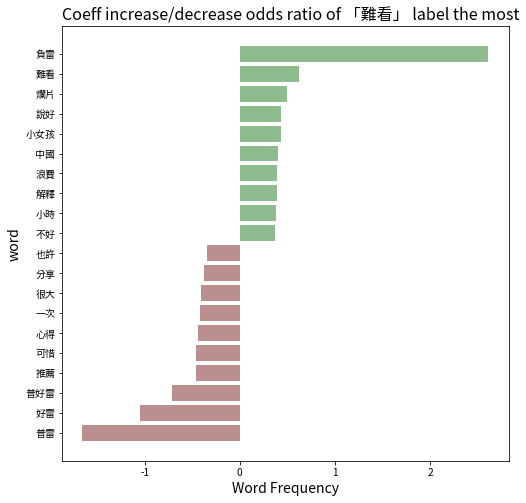

In [78]:
plot_coef(model_set['clf_logistic'], feature_names=vectorizer.get_feature_names(), top_n=10)

「兩岸」中高係數的字多半與中國有關；「股市」則是投資、金融市場相關的字；而因為三月剛好是經典賽期間，「運動」中影響最大的字是經典。

## 6. 預測新聞類別

In [ ]:
ct = pd.read_csv("./raw_data/ct_news_04.csv")
ct.dropna(inplace=True)
ct

,system_id,artUrl,artCatagory,artTitle,artDate,artContent,dataSource
0,1,https://www.chinatimes.com/newspapers/20230401...,政治,外媒爆 蔡總統雷根圖書館演說恐生變,2023-04-01 04:10:00,蔡英文總統出訪中美洲友邦途中過境美國，美東時間3月30日晚間，在紐約受邀出席美國「哈德遜研究...,chinatimes
1,2,https://www.chinatimes.com/newspapers/20230401...,政治,挺侯聯盟第1波 10藍委籲黨中央速徵召,2023-04-01 04:10:00,國民黨2024總統大選將以徵召方式決定人選，黨中央雖已積極展開徵詢，但目前黨內最強母雞就是新...,chinatimes
2,3,https://www.chinatimes.com/newspapers/20230401...,政治,徐弘庭斥黨員投票水很深 宣布退選,2023-04-01 04:10:00,國民黨立委初選內鬥不斷，台北市第8選區（中正、文山）初選方式採37制，原本有意投入初選的北市...,chinatimes
3,4,https://www.chinatimes.com/newspapers/20230401...,政治,曾銘宗：侯目前民調是地板 表態後會上升,2023-04-01 04:10:00,曾多次準確預測台灣選舉結果的日本學者小笠原欣幸，日前評價國民黨潛在候選人、新北市長侯友宜民調...,chinatimes
4,5,https://www.chinatimes.com/newspapers/20230401...,政治,郝龍斌支持徵召 籲朱立倫公開說不選總統,2023-04-01 04:10:00,國民黨中央日前拍板以徵召方式提名2024總統參選人，但提名辦法、時程遲未公布，黨內憂心持續拖...,chinatimes
...,...,...,...,...,...,...,...
276,357,https://www.chinatimes.com/realtimenews/202304...,體育,T1聯盟》魔獸眼傷未癒 雲豹緊急宣告明天與英熊之戰不打,2023-04-01 20:10:00,為了避免出現去年12月18日「魔獸」霍華德說要打卻又突然不打的「鬧劇」，桃園永豐雲豹直到2日...,chinatimes
277,358,https://www.chinatimes.com/realtimenews/202304...,體育,中職》「覺得是個機會」 廖健富代打轟3分炮助桃猿逆轉兄弟,2023-04-01 21:05:00,中職34年新球季開打，樂天桃猿靠著代打的廖健富從中信兄弟王牌投手德保拉手中轟出逆轉3分炮，率...,chinatimes
278,359,https://www.chinatimes.com/realtimenews/202304...,體育,中職》十大好糗被笑翻 陳晨威漏踩壘包生涯頭一遭,2023-04-01 21:34:00,樂天桃猿快腿陳晨威在新球季開幕戰發生漏踩壘包，被促請裁決出局，回到休息室被隊友笑翻，還被郭永...,chinatimes
279,360,https://www.chinatimes.com/realtimenews/202304...,體育,中職》宋嘉翔開幕戰蹲捕獲好評 曾豪駒打100分,2023-04-01 21:52:00,樂天桃猿去年季中選秀首輪選進的捕手宋嘉翔擔綱開幕戰先發蹲捕任務，以18歲253天之齡打破開幕...,chinatimes


In [ ]:
# 移除網址格式
ct["artContent"].str.replace("(http|https)://.*", "", regex=True)
ct["artTitle"].str.replace("(http|https)://.*", "", regex=True)
ct["artContent"].str.replace("[^\u4e00-\u9fa5]+", "", regex=True)
ct["artTitle"].str.replace("[^\u4e00-\u9fa5]+", "", regex=True)

# 留下 content
ct["content"] = ct["artTitle"] + ct["artContent"]
ct = ct.loc[:,["content", "artUrl", "artCatagory"]]  # 文章內容 文章連結

# 設定斷詞 function
def getToken(row):
    seg_list = jieba.cut(row, cut_all=False)
    seg_list = [
        w for w in seg_list if w not in stopWords and len(w) > 1
    ]  # 篩選掉停用字與字元數大於1的詞彙
    return seg_list

ct["words"] = ct["content"].apply(getToken).map(" ".join)
ct.head()

,content,artUrl,artCatagory,words
0,外媒爆 蔡總統雷根圖書館演說恐生變蔡英文總統出訪中美洲友邦途中過境美國，美東時間3月30日晚...,https://www.chinatimes.com/newspapers/20230401...,政治,外媒爆 總統 雷根 圖書館 演說 生變 英文 總統 出訪 中美洲 友邦 途中 過境 美國 美...
1,挺侯聯盟第1波 10藍委籲黨中央速徵召國民黨2024總統大選將以徵召方式決定人選，黨中央雖已...,https://www.chinatimes.com/newspapers/20230401...,政治,挺侯 聯盟 10 藍委籲 黨中央 徵召 國民黨 2024 總統大選 將以 徵召 方式 決定 ...
2,徐弘庭斥黨員投票水很深 宣布退選國民黨立委初選內鬥不斷，台北市第8選區（中正、文山）初選方式...,https://www.chinatimes.com/newspapers/20230401...,政治,徐弘庭斥 黨員 投票 宣布 退選 國民黨 立委 初選 不斷 台北市 選區 中正 文山 初選 ...
3,曾銘宗：侯目前民調是地板 表態後會上升曾多次準確預測台灣選舉結果的日本學者小笠原欣幸，日前評...,https://www.chinatimes.com/newspapers/20230401...,政治,曾銘宗 目前 民調 地板 表態 上升 曾多次 準確 預測 台灣 選舉 日本 學者 小笠 欣幸...
4,郝龍斌支持徵召 籲朱立倫公開說不選總統國民黨中央日前拍板以徵召方式提名2024總統參選人，但...,https://www.chinatimes.com/newspapers/20230401...,政治,郝龍斌 支持 徵召 籲朱 立倫公 開說 不選 總統 國民黨中央 日前 拍板 徵召 方式 提名...


In [ ]:
udn['artCatagory'].value_counts()

普通    677
好看    540
難看    540
Name: artCatagory, dtype: int64

In [ ]:
mapper = {"財經":"股市", "政治":"兩岸", "體育":"運動", "兩岸": "兩岸"}
ct['artCatagory'] = ct['artCatagory'].map(mapper)

X = ct['words']
y = ct['artCatagory']
y_pred = model_set[best_model_name].predict(vectorizer.transform(X))
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

          兩岸       0.65      0.88      0.75       106
          股市       0.90      0.65      0.76       142
          運動       0.89      0.97      0.93        32

    accuracy                           0.78       280
   macro avg       0.81      0.83      0.81       280
weighted avg       0.81      0.78      0.77       280



In [ ]:
ct['pred'] = y_pred
ct.loc[:,['words', 'artCatagory',"pred"]]

,words,artCatagory,pred
0,外媒爆 總統 雷根 圖書館 演說 生變 英文 總統 出訪 中美洲 友邦 途中 過境 美國 美...,兩岸,兩岸
1,挺侯 聯盟 10 藍委籲 黨中央 徵召 國民黨 2024 總統大選 將以 徵召 方式 決定 ...,兩岸,兩岸
2,徐弘庭斥 黨員 投票 宣布 退選 國民黨 立委 初選 不斷 台北市 選區 中正 文山 初選 ...,兩岸,股市
3,曾銘宗 目前 民調 地板 表態 上升 曾多次 準確 預測 台灣 選舉 日本 學者 小笠 欣幸...,兩岸,兩岸
4,郝龍斌 支持 徵召 籲朱 立倫公 開說 不選 總統 國民黨中央 日前 拍板 徵召 方式 提名...,兩岸,兩岸
...,...,...,...
276,T1 聯盟 魔獸 眼傷 雲豹 緊急 宣告 明天 英熊 之戰 避免出現 去年 12 18 魔獸...,運動,運動
277,中職 覺得 機會 廖健富 代打 分炮助 桃猿 逆轉 兄弟 中職 34 球季 開打 樂天 桃猿...,運動,運動
278,中職 十大 晨威漏 生涯 一遭 樂天 桃猿快 晨威 球季 開幕 發生 促請 裁決 出局 回到...,運動,運動
279,中職 宋嘉翔 開幕 捕獲 好評 曾豪駒 100 樂天 桃猿 去年 季中 選秀 首輪 選進 捕...,運動,運動


In [ ]:
false_pred = ct.query("artCatagory != pred").loc[:,['words', 'artCatagory',"pred"]]
false_pred

,words,artCatagory,pred
2,徐弘庭斥 黨員 投票 宣布 退選 國民黨 立委 初選 不斷 台北市 選區 中正 文山 初選 ...,兩岸,股市
12,鳳馨 受害 王鴻薇 政府 台灣成 詐騙 之島 臉書 假冒 名人 詐騙 事件 相當 猖獗 作家...,兩岸,股市
26,立院 組挺侯 聯盟 侯友宜 齊心 齊力 國民黨 將以 徵召 方式 決定 2024 總統大選 ...,兩岸,股市
30,視察 清明 服務 總統 侯友宜 心連心 清明 連假 第一天 新北 各區 公墓 及納 骨塔 湧...,兩岸,運動
34,信回 台南 立委 成立 競辦 誓言 國民黨 搶下 一席 國民黨 分區 立委 信回 故鄉 台南...,兩岸,股市
...,...,...,...
210,反擊 拜登 第一槍 大陸 美光 美媒 晶片 大廠 危險 科技 戰愈 激烈 禁令 擴大 大陸 ...,股市,兩岸
211,全球 債務 狂飆 投資 大師 災難 降臨 遠超 2008 近期 銀行業 動盪 市場 惶恐不安...,股市,兩岸
212,蔚來 汽車 跨界 製造 手機 預計 今年 第三季 發布 香港 信報 報導 去年 李斌 透露 ...,股市,兩岸
213,人民幣 影響力 巴西 第二 外匯存底 貨幣 中國 央視 報導 巴西 央行 最新 報告 指出 ...,股市,兩岸


In [ ]:
false_pred.loc[false_pred['artCatagory']=='股市', :]

,words,artCatagory,pred
73,跟隨 美國 腳步 中國 日本 限制 23 半導體 設備 出口 日本 經濟 產業 大臣 西村 ...,股市,兩岸
74,反制 第一槍 陸對 美光 產品 啟動 網路 安全 審查 中國 網信 31 晚間 公告 保障 ...,股市,兩岸
78,製造業 PMI 預期 大陸 防疫 鬆綁 經濟 持續 回升 大陸 國家統計局 31 公布 製造...,股市,兩岸
80,加速 復甦 世銀上 東亞 今年 經濟 成長 世銀 預測 EAP 包括 大陸 在內 23 經濟...,股市,兩岸
84,晶片 法案 委屈 台廠 經部 協助 溝通 美國 晶片 法案 鉅額 補貼 廣邀 世界 各國 半...,股市,兩岸
87,電信業 五變 旭東 嫌多 國內 兩大 電信 合併案 NCC 已有 條件 核准 公平 核准 國...,股市,兩岸
89,發現 提早 入帳 數位 發展部 晚間 對此 表示 原則上 連假 第一個 營業日 日起 000...,股市,兩岸
91,立委 力倡 主權 基金 央行 不宜 挪用 外匯存底 行政院長 陳建仁 立法院 備詢 民眾 黨...,股市,兩岸
94,脫歐 最大 進展 加入 CPTPP 英國 31 宣布 敲定 加入 太平洋 夥伴 全面進步 協...,股市,兩岸
95,鄧振中 積極爭取 台灣 入會 鄧振中 專心 處理 英國 關係 過去 會員國 尚未 台灣 大陸...,股市,兩岸


In [ ]:
pprint(false_pred['words'][74])

('反制 第一槍 陸對 美光 產品 啟動 網路 安全 審查 中國 網信 31 晚間 公告 保障 關鍵 資訊 基礎設施 供應鏈 安全 防範 產品 問題 隱患 '
 '造成 網路 安全 風險 維護 國家 安全 網路 安全 審查 辦公室 將依 國家 安全法 網絡安全 網路 安全 審查 辦法 美光 公司 銷售 產品 實施 '
 '網路 安全 審查 此前 中國 網路 安全 審查 先後 2021 針對 滴滴 出行 滿滿 貨車 BOSS 直聘 大陸 互聯網 平台 實施 成為 中企 境外 '
 '上市 監管 措施 一環 本次 網信 美光 啟動 網路 安全 審查 應是 外企 實施 首例 中國 晶片 近期 遭美 荷等國 加強 圍堵 值得注意 中國 '
 '記憶體 晶片 大廠 長江 存儲 列入 美國 貿易 黑名單 陸媒集 微網 披露 美光 背後 始作俑者 一直 政治 投機者 角色 美國 遊說 數據 顯示 '
 '2018 以來 美國政府 遊說 次數 最多 美國 半導體 企業 年來 斥資 954 萬美元 用於 遊說 唯一 提出 中國 競爭 相關 問題 公司')


模型對另一個新聞網的預測結果比較普通。不過，其中很大一部分預測錯的類別，是把「股市」預測成「兩岸」。當我們把這個類別的錯誤挑出來看，可以發現這些預測錯的股市新聞，多半也算與國際地緣政治相關的財經新聞。

* accuracy可能會因為資料分布不同而有所偏差，所以評估模型的時候，可以加入一起 F1-score, recall, precision, AUC 等常見分類任務指標來評估。
* 在這裡可以看到個不同模型的 F1-score 都不會差到太多，代表就算只用 1000 維的 DTM 來代表一篇文章，其實也是有一定程度地的預測能力。

## 6. 教學目標
1. 能夠利用 DTM 將文章表示成一串數字，以利後續的分析或預測任務使用
2. 能夠使用機器學習流程，訓練一個文集分類模型
    * 額外提問：只要能夠把文字資料轉換成 `input` 與 `label` 的形式，就能夠來訓練預測模型。例如本週就是將新聞轉成數字 input，label 為新聞類別。文字分析中有哪些可能的應用場景？
        * 用企業的財報預測企業股價/ROA?
        * 用總統候選人的選前演講稿預測得票率？
3. 能夠解釋在可解釋模型中，詞頻/tfidf 作為 input feature 的意義

## 附錄

In [ ]:
# 定義模型訓練組合
## 不做 cross validation, 用 test data 來評估模型的版本
## pipeline: 資料處理 vectorizer + 分類器
def train(vectorizer, clf, X_train, y_train, X_test, y_test):

    ## train classifier
    vec_train = vectorizer.fit_transform(X_train).toarray()
    vec_test = vectorizer.transform(X_test).toarray()
    clf.fit(vec_train, y_train)
    

    ## test classifier
    y_pred = clf.predict(vec_test)
    y_pred_proba = clf.predict_proba(vec_test)

    label_binarizer = LabelBinarizer()
    label_binarizer.fit(y_train)
    y_onehot_test = label_binarizer.transform(y_test)

    ## Accuracy, Precision, Recall, F1-score
    print(classification_report(y_test, y_pred))

    classes = clf.classes_
    ## Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots()
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=plt.cm.Blues, cbar=False)
    ax.set(
        xlabel="Pred",
        ylabel="True",
        xticklabels=classes,
        yticklabels=classes,
        title="Confusion matrix",
    )
    plt.yticks(rotation=0)

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

    ## Plot roc
    for i in range(len(classes)):
        fpr, tpr, thresholds = roc_curve(y_onehot_test[:, i], y_pred_proba[:, i])
        ax[0].plot(
            fpr,
            tpr,
            lw=3,
            label="{0} (area={1:0.2f})".format(classes[i], auc(fpr, tpr)),
        )
    ax[0].plot([0, 1], [0, 1], color="navy", lw=3, linestyle="--")
    ax[0].set(
        xlim=[-0.05, 1.0],
        ylim=[0.0, 1.05],
        xlabel="False Positive Rate",
        ylabel="True Positive Rate (Recall)",
        title="Receiver operating characteristic",
    )
    ax[0].legend(loc="lower right")
    ax[0].grid(True)

    ## Plot precision-recall curve
    for i in range(len(classes)):
        precision, recall, thresholds = precision_recall_curve(
            y_onehot_test[:, i], y_pred_proba[:, i]
        )
        ax[1].plot(
            recall,
            precision,
            lw=3,
            label="{0} (area={1:0.2f})".format(classes[i], auc(recall, precision)),
        )
    ax[1].set(
        xlim=[0.0, 1.05],
        ylim=[0.0, 1.05],
        xlabel="Recall",
        ylabel="Precision",
        title="Precision-Recall curve",
    )
    ax[1].legend(loc="best")
    ax[1].grid(True)

    plt.show()

    # return the model object
    return classification_report(y_test, y_pred, output_dict=True)


              precision    recall  f1-score   support

          兩岸       0.98      0.98      0.98       526
          股市       0.99      0.99      0.99       677
          運動       1.00      0.99      1.00       593

    accuracy                           0.99      1796
   macro avg       0.99      0.99      0.99      1796
weighted avg       0.99      0.99      0.99      1796



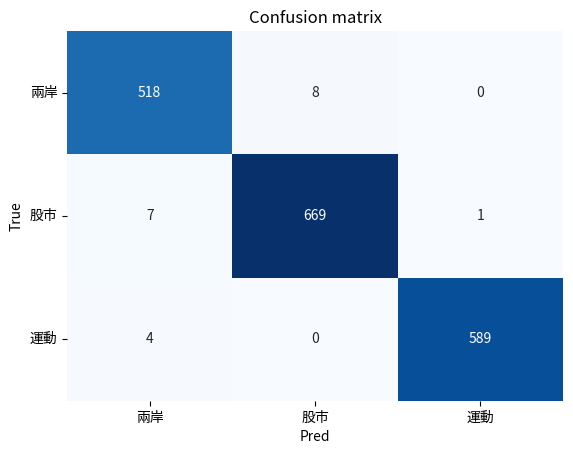

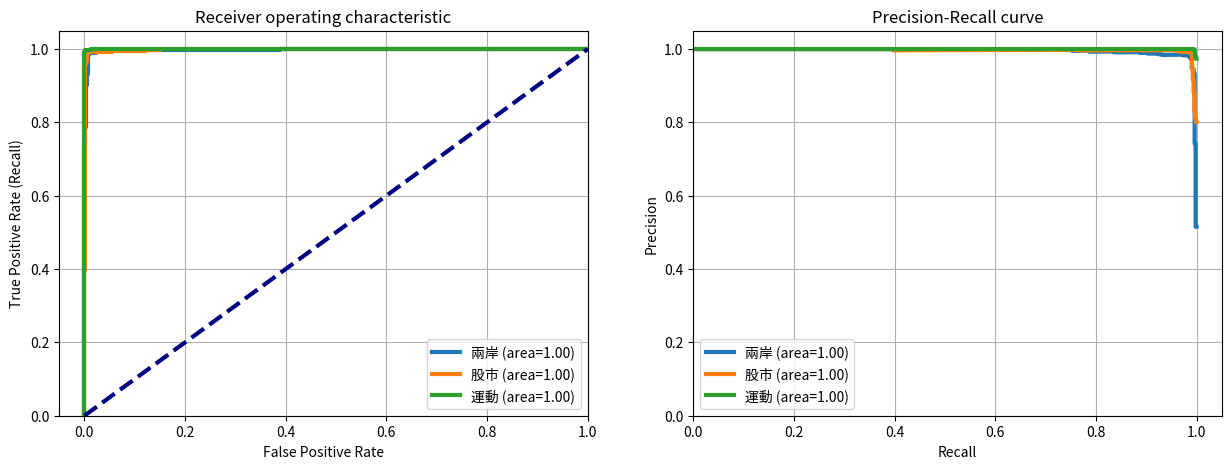

{'兩岸': {'precision': 0.9792060491493384,
  'recall': 0.9847908745247148,
  'f1-score': 0.9819905213270143,
  'support': 526},
 '股市': {'precision': 0.9881831610044313,
  'recall': 0.9881831610044313,
  'f1-score': 0.9881831610044313,
  'support': 677},
 '運動': {'precision': 0.9983050847457627,
  'recall': 0.9932546374367622,
  'f1-score': 0.9957734573119189,
  'support': 593},
 'accuracy': 0.9888641425389755,
 'macro avg': {'precision': 0.9885647649665108,
  'recall': 0.9887428909886361,
  'f1-score': 0.9886490465477881,
  'support': 1796},
 'weighted avg': {'precision': 0.9888960451596821,
  'recall': 0.9888641425389755,
  'f1-score': 0.9888756538997647,
  'support': 1796}}

In [ ]:
data = udn
X = data["words"]
y = data["artCatagory"]
# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777
)
vectorizer = CountVectorizer(max_features=1000)
clf = LogisticRegression()
train(vectorizer, clf, X_train, y_train, X_test, y_test)

    畫出決策樹的 code

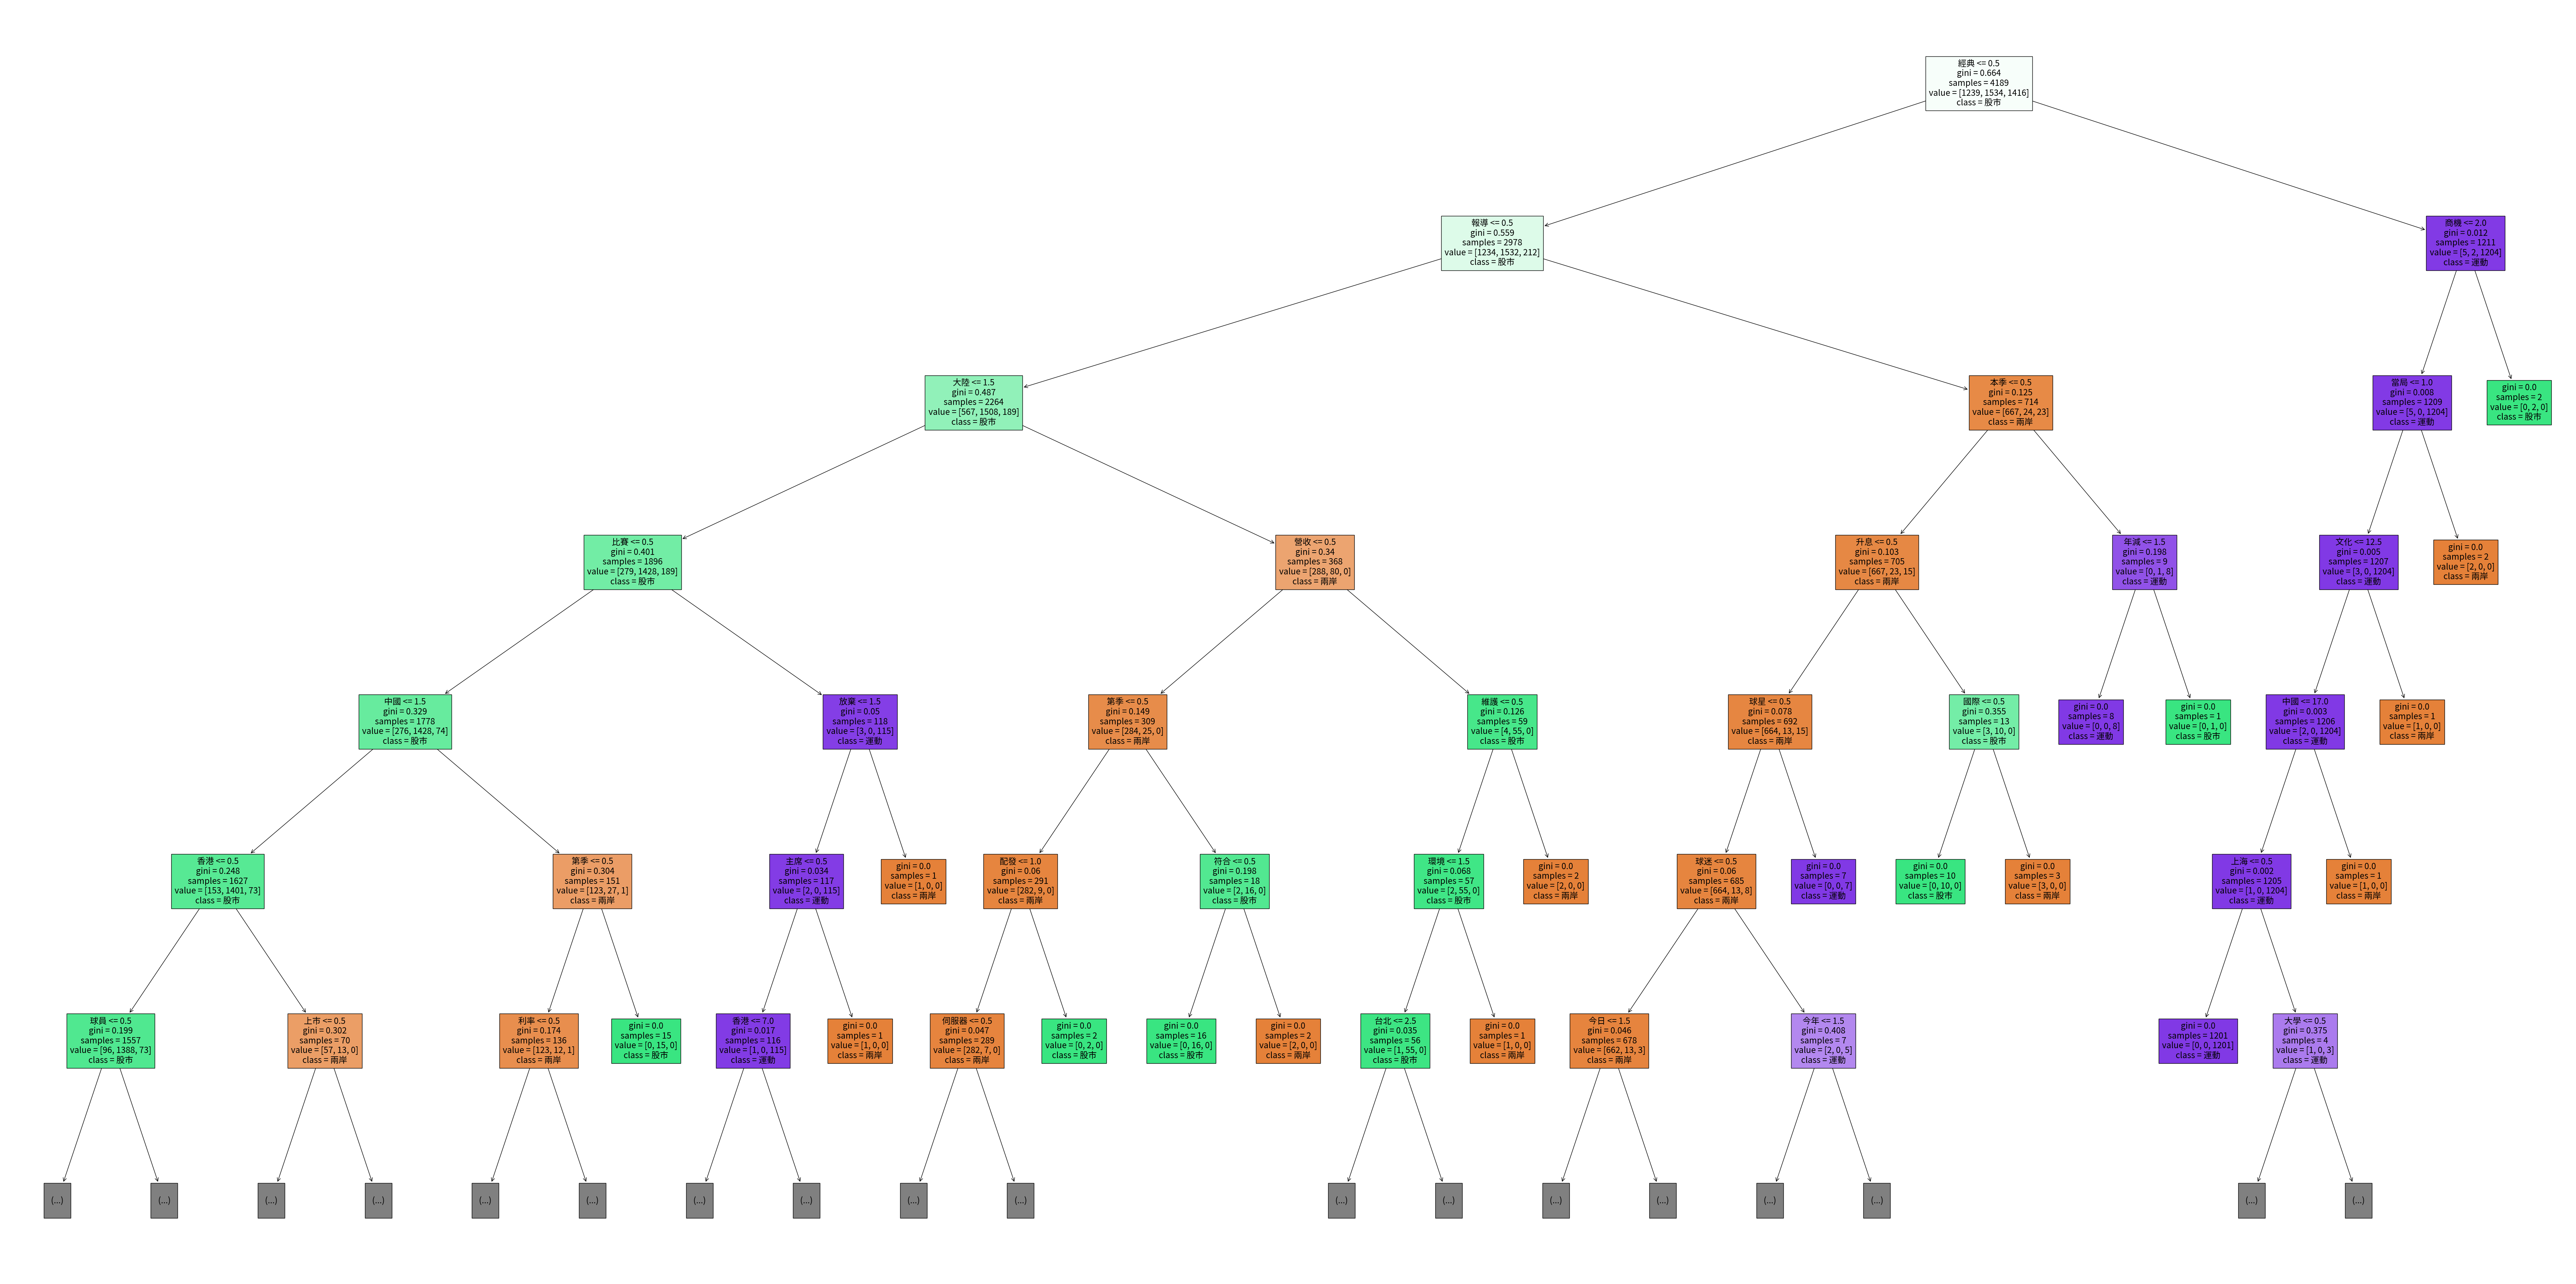

In [ ]:
fig = plt.figure()
fig.set_size_inches(90, 45)
plot_tree(
    model_set["clf_dtree"], 
    max_depth=6, # 最大深度
    feature_names=vectorizer.get_feature_names(), 
    class_names=model_set["clf_dtree"].classes_,
    filled=True
)
fig.savefig("decistion_tree.png")